In [1]:
import sys
print(sys.executable)

C:\Users\HP\anaconda3\envs\tfenv\python.exe


In [2]:
conda activate tfenv


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sklearn
print(sklearn.__version__)

1.7.2


In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install seaborn

In [9]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fake = pd.read_csv("fake_users.csv")
real = pd.read_csv("real_users.csv")  #LOAD DATASET

In [3]:
fake["Label"] = 1      # Fake

real["Label"] = 0      # Genuine

In [4]:
df = pd.concat([fake, real], ignore_index=True)

In [5]:
print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

             id             name  screen_name  statuses_count  \
0  1.664073e+09    Lavona Keller    kellervxg       13.093733   
1  7.296345e+08  Elizabet Graves          NaN        0.000000   
2  1.214885e+09   Estelle Santos  estellesant       52.941642   
3 -0.000000e+00      Patsy Weiss     patsyyor       18.857321   
4  1.844412e+09       Cindy Cook          NaN       51.167110   

   followers_count  friends_count  favourites_count  listed_count  \
0        -0.000000       0.000000               0.0           0.0   
1         0.000000       0.000000               0.0           0.0   
2        -0.000000     518.508286              -0.0          -0.0   
3         0.000000    1059.138617               0.0           0.0   
4         7.368223       0.000000               0.0           0.0   

                       created_at  url  ...  \
0  Sun Jun 24 03:26:11 +0000 2012 -0.0  ...   
1  Mon Jun 25 02:06:59 +0000 2012  0.0  ...   
2  Sat Jun 23 19:48:28 +0000 2012 -0.0  ...   
3  Sat

In [6]:
print(df.isnull().sum())

id                                       0
name                                  1740
screen_name                           1770
statuses_count                           0
followers_count                          0
friends_count                            0
favourites_count                         0
listed_count                             0
created_at                            1739
url                                   1986
lang                                  1770
time_zone                             3879
location                              2319
default_profile                          0
default_profile_image                    0
geo_enabled                              0
profile_image_url                     1789
profile_banner_url                    3922
profile_use_background_image             0
profile_background_image_url_https    1731
profile_text_color                    1751
profile_image_url_https               1769
profile_sidebar_border_color          1796
profile_bac

In [7]:
drop_cols = [
'id',
'name',
'screen_name',
'profile_image_url',
'profile_banner_url',
'profile_background_image_url',
'profile_background_image_url_https',
'profile_image_url_https',
'updated',
'url',
'location',
'time_zone'
]

df.drop(columns=drop_cols,inplace=True,errors='ignore')

In [8]:
df.fillna("Unknown", inplace=True)

In [9]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=le.fit_transform(df[col].astype(str))

In [10]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train) #TRAIN_RANDOMFOREST

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
pred = rf.predict(X_test)  #PREDICTION

In [16]:
acc = accuracy_score(y_test,pred) #ACCURACY

print("Accuracy :",acc*100)

Accuracy : 98.9


In [26]:
print(classification_report(y_test,pred)) #CLASSIFICATION

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       500
           1       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



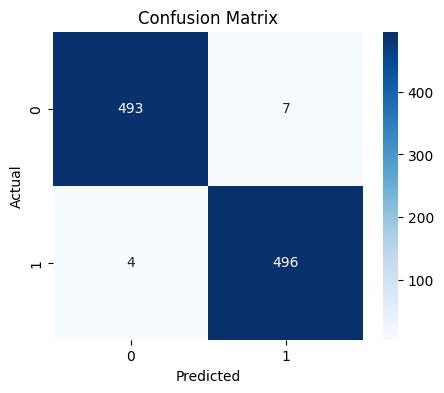

In [27]:
#CONFUSION_MATRIX 
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,

annot=True,

fmt="d",

cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [28]:
importance = pd.Series(

rf.feature_importances_,

index=X.columns

).sort_values(ascending=False)

print(importance.head(10))

dataset                     0.295453
lang                        0.181985
favourites_count            0.101268
statuses_count              0.080304
followers_count             0.055979
utc_offset                  0.053180
profile_background_color    0.051957
listed_count                0.037235
geo_enabled                 0.034590
default_profile             0.019322
dtype: float64


In [29]:
sample = X.iloc[[10]]

prediction = rf.predict(sample)

if prediction[0]==1:

    print("Fake Profile")

else:

    print("Genuine Profile")

Fake Profile


Fake Dataset : (2500, 34)
Real Dataset : (2500, 34)

Merged Dataset Shape : (5000, 35)

First 5 Rows
             id             name  screen_name  statuses_count  \
0  1.664073e+09    Lavona Keller    kellervxg       13.093733   
1  7.296345e+08  Elizabet Graves          NaN        0.000000   
2  1.214885e+09   Estelle Santos  estellesant       52.941642   
3 -0.000000e+00      Patsy Weiss     patsyyor       18.857321   
4  1.844412e+09       Cindy Cook          NaN       51.167110   

   followers_count  friends_count  favourites_count  listed_count  \
0        -0.000000       0.000000               0.0           0.0   
1         0.000000       0.000000               0.0           0.0   
2        -0.000000     518.508286              -0.0          -0.0   
3         0.000000    1059.138617               0.0           0.0   
4         7.368223       0.000000               0.0           0.0   

                       created_at  url  ...  \
0  Sun Jun 24 03:26:11 +0000 2012 -0.0  ...   

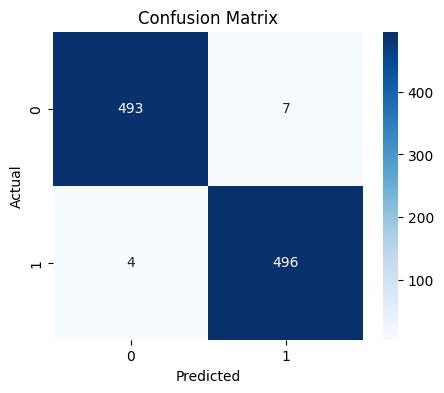


Top 10 Important Features

                       Feature  Importance
22                     dataset    0.268282
7                         lang    0.202175
4             favourites_count    0.111269
1               statuses_count    0.080108
18                  utc_offset    0.064340
2              followers_count    0.062649
16    profile_background_color    0.034965
10                 geo_enabled    0.034267
5                 listed_count    0.030439
15  profile_sidebar_fill_color    0.018087

Prediction for Sample Profile
❌ Fake Profile


In [31]:

# 1. Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load Dataset


fake = pd.read_csv("fake_users.csv")
real = pd.read_csv("real_users.csv")

print("Fake Dataset :", fake.shape)
print("Real Dataset :", real.shape)


# 3. Create Labels


fake["Label"] = 1
real["Label"] = 0


# 4. Merge Dataset


df = pd.concat([fake, real], ignore_index=True)

print("\nMerged Dataset Shape :", df.shape)


# 5. Dataset Information


print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


# 6. Remove Unnecessary Columns


drop_cols = [
    "name",
    "screen_name",
    "profile_image_url",
    "profile_banner_url",
    "profile_background_image_url",
    "profile_background_image_url_https",
    "profile_image_url_https",
    "updated",
    "url",
    "location",
    "time_zone"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")


# 7. Handle Missing Values


df.fillna("Unknown", inplace=True)


# 8. Encode Categorical Data


le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))


# 9. Features & Target


X = df.drop("Label", axis=1)
y = df["Label"]


# 10. Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))


# 11. Train Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


# 12. Prediction


pred = rf.predict(X_test)


# 13. Accuracy


accuracy = accuracy_score(y_test, pred)

print("\nAccuracy :", round(accuracy*100,2), "%")


# 14. Classification Report


print("\nClassification Report\n")

print(classification_report(y_test, pred))


# 15. Confusion Matrix


cm = confusion_matrix(y_test, pred)

print("\nConfusion Matrix\n")

print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# 16. Feature Importance


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features\n")

print(importance.head(10))


# 17. Predict One Sample


sample = X.iloc[[10]]

prediction = rf.predict(sample)

print("\nPrediction for Sample Profile")

if prediction[0] == 1:

    print("❌ Fake Profile")

else:

    print("✅ Genuine Profile")